# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [2]:
# TODO(0.1): load config / verify env vars
from config import DATABRICKS_HOST, DATABRICKS_MODEL,DATABRICKS_TOKEN, EMBEDDINGS_ENDPOINT, UC_CATALOG, UC_SCHEMA, VECTOR_SEARCH_ENDPOINT, VECTOR_SEARCH_INDEX

env_vars = {
    "DATABRICKS_HOST": DATABRICKS_HOST,
    "DATABRICKS_TOKEN": DATABRICKS_TOKEN,
    "DATABRICKS_MODEL": DATABRICKS_MODEL,
    "EMBEDDINGS_ENDPOINT": EMBEDDINGS_ENDPOINT,
    "UC_CATALOG": UC_CATALOG,
    "UC_SCHEMA": UC_SCHEMA,
    "VECTOR_SEARCH_ENDPOINT": VECTOR_SEARCH_ENDPOINT,
    "VECTOR_SEARCH_INDEX": VECTOR_SEARCH_INDEX,
}

print("Checking environment variables...\n")

missing = []
for key, value in env_vars.items():
    if value:
        if key in ("DATABRICKS_TOKEN","DATABRICKS_HOST"):
            print(f"✅ {key}: {'*' * 10}")
        else:
            print(f"✅ {key}: {value}")
    else:
        print(f"❌ {key}: NOT SET")
        missing.append(key)

if missing:
    raise EnvironmentError(
        f"\nMissing environment variables: {', '.join(missing)}"
    )

print("\nAll environment variables loaded successfully!")



Checking environment variables...

✅ DATABRICKS_HOST: **********
✅ DATABRICKS_TOKEN: **********
✅ DATABRICKS_MODEL: databricks-meta-llama-3-3-70b-instruct
✅ EMBEDDINGS_ENDPOINT: databricks-gte-large-en
✅ UC_CATALOG: main
✅ UC_SCHEMA: default
✅ VECTOR_SEARCH_ENDPOINT: mehmood-vs-endpoint
✅ VECTOR_SEARCH_INDEX: main.default.mehmood_analyst_index

All environment variables loaded successfully!


In [0]:
display(dbutils.fs.ls("/Volumes/main/default/pa4/"))

path,name,size,modificationTime
dbfs:/Volumes/main/default/pa4/annual_report.pdf,annual_report.pdf,22167,1784298934000


In [0]:
spark.sql("SHOW FUNCTIONS").filter("function like '%ai_parse%'").show()

+-----------------+
|         function|
+-----------------+
|ai_parse_document|
+-----------------+



In [0]:
%pip install databricks-vectorsearch

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
# TODO(0.3): ingest corpus -> Delta table -> Vector Search index; wait until READY
# from rag.ingest import ingest
# ingest(spark, volume_path='/Volumes/main/default/pa4/annual_report.pdf')

import os
from datetime import timedelta
from databricks.vector_search.client import VectorSearchClient

UC_CATALOG = "main"
UC_SCHEMA = "default"
EMBEDDINGS_ENDPOINT = "databricks-gte-large-en"
VECTOR_SEARCH_ENDPOINT = "mehmood-vs-endpoint" 
VECTOR_SEARCH_INDEX = "main.default.mehmood_analyst_index"

VOLUME_PATH = "/Volumes/main/default/pa4"
PDF_FILE = "annual_report.pdf"
FULL_PDF_PATH = f"{VOLUME_PATH}/{PDF_FILE}"

# Tables that will be created
PARSE_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.pa4_parsed_documents"
CHUNK_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.pa4_chunks"

print("📋 Configuration")
print(f"   PDF         : {FULL_PDF_PATH}")
print(f"   Parse table : {PARSE_TABLE}")
print(f"   Chunk table : {CHUNK_TABLE}")
print(f"   VS endpoint : {VECTOR_SEARCH_ENDPOINT}")
print(f"   VS index    : {VECTOR_SEARCH_INDEX}\n")

try:
    files = dbutils.fs.ls(VOLUME_PATH)
    if not any(f.name == PDF_FILE for f in files):
        raise FileNotFoundError(f"{PDF_FILE} not found in {VOLUME_PATH}")
    print("✅ PDF found in volume.\n")
except Exception as e:
    print(f"❌ PDF not accessible: {e}")
    raise
print("1/4 Parsing PDF with ai_parse_document ...")

spark.sql(f"CREATE CATALOG IF NOT EXISTS {UC_CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {UC_CATALOG}.{UC_SCHEMA}")

spark.sql(f"""
    CREATE TABLE IF NOT EXISTS {PARSE_TABLE} (
        path STRING,
        parsed VARIANT
    ) TBLPROPERTIES (delta.enableChangeDataFeed = true)
""")

spark.sql(f"""
    INSERT OVERWRITE {PARSE_TABLE}
    SELECT
        path,
        ai_parse_document(content) AS parsed
    FROM read_files('{FULL_PDF_PATH}', format => 'binaryFile')
""")

parsed_count = spark.table(PARSE_TABLE).count()
print(f"   Parsed {parsed_count} document(s) into {PARSE_TABLE}.\n")

print("2/4 Chunking with ai_prep_search ...")

spark.sql(f"""
    CREATE TABLE IF NOT EXISTS {CHUNK_TABLE} (
        chunk_id STRING,
        chunk_to_retrieve STRING,
        chunk_to_embed STRING,
        source STRING,
        page STRING
    ) TBLPROPERTIES (delta.enableChangeDataFeed = true)
""")

spark.sql(f"""
    INSERT OVERWRITE {CHUNK_TABLE}
    SELECT
        chunk.value:chunk_id::STRING AS chunk_id,
        chunk.value:chunk_to_retrieve::STRING AS chunk_to_retrieve,
        chunk.value:chunk_to_embed::STRING AS chunk_to_embed,
        prepped.path AS source,
        chunk.value:pages[0].page_id::STRING AS page
    FROM (
        SELECT path, ai_prep_search(parsed) AS result FROM {PARSE_TABLE}
    ) prepped,
        LATERAL variant_explode(prepped.result:document.contents) AS chunk
""")

chunk_count = spark.table(CHUNK_TABLE).count()
print(f"   Created {chunk_count} chunks in {CHUNK_TABLE}.\n")
print("3/4 Creating / verifying Vector Search resources ...")

client = VectorSearchClient()

existing_endpoints = [e["name"] for e in client.list_endpoints().get("endpoints", [])]
if VECTOR_SEARCH_ENDPOINT not in existing_endpoints:
    client.create_endpoint(name=VECTOR_SEARCH_ENDPOINT, endpoint_type="STANDARD")
    print(f"   Created endpoint '{VECTOR_SEARCH_ENDPOINT}'.")
else:
    print(f"   Endpoint '{VECTOR_SEARCH_ENDPOINT}' already exists.")

existing_indexes = [
    idx["name"] for idx in client.list_indexes(name=VECTOR_SEARCH_ENDPOINT).get("vector_indexes", [])
]
if VECTOR_SEARCH_INDEX not in existing_indexes:
    client.create_delta_sync_index(
        endpoint_name=VECTOR_SEARCH_ENDPOINT,
        index_name=VECTOR_SEARCH_INDEX,
        source_table_name=CHUNK_TABLE,
        pipeline_type="TRIGGERED",
        primary_key="chunk_id",
        embedding_source_column="chunk_to_retrieve",
        embedding_model_endpoint_name=EMBEDDINGS_ENDPOINT,
    )
    print(f"   Created index '{VECTOR_SEARCH_INDEX}'.")
else:
    print(f"   Index '{VECTOR_SEARCH_INDEX}' already exists.")

print("\n4/4 Waiting for index to become READY (this may take several minutes) ...")
index = client.get_index(endpoint_name=VECTOR_SEARCH_ENDPOINT, index_name=VECTOR_SEARCH_INDEX)
index.wait_until_ready(timeout=timedelta(seconds=1800))

test = index.similarity_search(
    query_text="What was the net revenue?",
    columns=["chunk_to_retrieve", "source"],
    num_results=1,
)
if test.get("result", {}).get("data_array"):
    print("✅ Index is READY and queryable.")
    sample_text = test["result"]["data_array"][0][0]
    print("   Sample chunk:", sample_text[:200], "...")
else:
    print("⚠️ Index READY but returned no results. Check your chunk table content.")

print("\n🎉 Ingestion complete. Your Vector Search index is ready for Part 1.")

/home/spark-680862a4-5602-4871-a821-2d/.ipykernel/308/command-8674810566005373-3610337354:4: DeprecationWarning: databricks-vectorsearch is deprecated and has been renamed to databricks-ai-search. Imports under 'databricks.vector_search.*' will continue to work as a thin re-export of 'databricks.ai_search.*', but new code should switch to 'pip install databricks-ai-search' and 'from databricks.ai_search.* import ...'.
  from databricks.vector_search.client import VectorSearchClient


📋 Configuration
   PDF         : /Volumes/main/default/pa4/annual_report.pdf
   Parse table : main.default.pa4_parsed_documents
   Chunk table : main.default.pa4_chunks
   VS endpoint : mehmood-vs-endpoint
   VS index    : main.default.mehmood_analyst_index

✅ PDF found in volume.

1/4 Parsing PDF with ai_parse_document ...
   Parsed 1 document(s) into main.default.pa4_parsed_documents.

2/4 Chunking with ai_prep_search ...
   Created 7 chunks in main.default.pa4_chunks.

3/4 Creating / verifying Vector Search resources ...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
   Created endpoint 'mehmood-vs-endpoint'.
   Created index 'main.default.mehmood_analyst_index'.

4/4 Waiting for index to become READY (this may take several minutes) ...
[NOTICE] Using a notebook authentication token. Recommended for development only. For i

In [0]:
from databricks.vector_search.client import VectorSearchClient

client = VectorSearchClient()
index = client.get_index(
    endpoint_name="mehmood-vs-endpoint",
    index_name="main.default.mehmood_analyst_index"
)

# Try the similarity search directly
try:
    results = index.similarity_search(
        query_text="What was net revenue in 2023?",
        columns=["chunk_to_retrieve", "source"],
        num_results=2
    )
    data = results.get("result", {}).get("data_array", [])
    if data:
        print("✅ Index is working! Sample chunk:")
        print(data[0][0][:2000], "...")
    else:
        print("⚠️ No results returned.")
except Exception as e:
    print("❌ Error during search:", e)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
✅ Index is working! Sample chunk:
td>3,680</td><td>4,070</td></tr><tr><td>Employees</td><td>196,000</td><td>199,000</td><td>203,000</td><td>206,000</td><td>210,000</td></tr></table>

Net revenue grew at a five-year compound annual growth rate (CAGR) of 10.7%, from ¥11,280 billion in FY2019 to ¥16,910 billion in FY2023. Earnings per share more than doubled over the same period to ¥640.

The following condensed statement of operations compares FY2023 with the prior fiscal year. All amounts are in billions of Japanese yen unless otherwise stated.

<table><tr><th>¥ billions</th

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [6]:
# Test: AnalystState definition is correct
from agent.state import AnalystState
from langgraph.graph import add_messages
from typing import get_type_hints

hints = get_type_hints(AnalystState)
required_fields = {'messages', 'plan', 'current_step_index', 'step_results', 'next_agent', 'final_answer'}
missing = required_fields - set(hints.keys())
if missing:
    print(f"❌ Missing fields: {missing}")
else:
    print("✅ All required fields present.")

# Check that 'messages' uses add_messages reducer
if hints.get('messages') is not None:
    print("✅ messages field defined.")
else:
    print("❌ messages field missing.")

✅ All required fields present.
✅ messages field defined.


In [7]:
# Test: Planner produces a valid plan
from agent.planner import make_planner
from config import get_chat_llm
from langchain_core.messages import HumanMessage

llm = get_chat_llm()
planner = make_planner(llm)

state = {"messages": [HumanMessage(content="What was net revenue in FY2023 and project 8% CAGR for 3 years?")]}
result = planner(state)

print("Plan:", result.get("plan"))
print("Index:", result.get("current_step_index"))
print("Step results:", result.get("step_results"))

# Basic validation
assert isinstance(result["plan"], list) and len(result["plan"]) >= 2, "Plan should contain 2+ steps"
assert result["current_step_index"] == 0
print("✅ Planner works.")

Plan: ['Retrieve: net revenue in FY2023', 'Compute: net revenue in FY2023 * (1 + 0.08)^3']
Index: 0
Step results: []
✅ Planner works.


In [8]:
# Test: Supervisor routes correctly
from agent.supervisor import make_supervisor
from config import get_chat_llm

llm = get_chat_llm()
supervisor = make_supervisor(llm)

# Simulate a retrieval step
state = {
    "plan": ["Retrieve: net revenue", "Compute: 15% growth"],
    "current_step_index": 0
}
print(supervisor(state))  # Expect {'next_agent': 'rag_agent'}

# Simulate a compute step
state["current_step_index"] = 1
print(supervisor(state))  # Expect {'next_agent': 'mcp_tools'}

# Simulate all steps done
state["current_step_index"] = 2
print(supervisor(state))  # Expect {'next_agent': 'synthesizer'}

print("✅ Supervisor works.")

{'next_agent': 'rag_agent'}
{'next_agent': 'mcp_tools'}
{'next_agent': 'synthesizer'}
✅ Supervisor works.


In [3]:
# Test: RAG agent retrieves and formats a fact
from agent.rag_agent import make_rag_agent
from rag.store import get_retriever
from config import get_chat_llm

llm = get_chat_llm()
retriever = get_retriever(k=3)
rag = make_rag_agent(retriever, llm)

state = {
    "plan": ["Retrieve: What was the net revenue in FY2023?"],
    "current_step_index": 0,
    "step_results": []
}
new_state = rag(state)
print("Step result:", new_state["step_results"][0])
print("Next index:", new_state["current_step_index"])
print("✅ RAG agent works.")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Step result: The net revenue in FY2023 was ¥16,910 billion.
Next index: 1
✅ RAG agent works.


In [3]:
# Test: MCP tools node performs a calculation
from agent.graph import make_mcp_node, load_mcp_tools
from config import get_chat_llm

llm = get_chat_llm()
tools = load_mcp_tools()   # This may start the MCP server in the background
mcp_node = make_mcp_node(tools, llm)

state = {
    "plan": ["Compute: What is 15% of 2400 ?"],
    "current_step_index": 0,
    "step_results": []
}
new_state = mcp_node(state)
print("Step result:", new_state["step_results"][-1])
print("✅ MCP tools node works.")

Step result: ([{'type': 'text', 'text': '0.15 * 2400 = 360', 'id': 'lc_5bfd61e1-9b59-4922-b163-99fda9286f38'}], {'structured_content': {'result': '0.15 * 2400 = 360'}})
✅ MCP tools node works.


In [4]:
# Test: Synthesizer produces a final answer
from agent.synthesizer import make_synthesizer
from config import get_chat_llm
from langchain_core.messages import HumanMessage

llm = get_chat_llm()
synth = make_synthesizer(llm)

state = {
    "messages": [HumanMessage(content="What was the revenue in FY2023?")],
    "step_results": [
        "Net revenue in FY2023 was ¥16.91 trillion [source: annual_report.pdf, page 4]"
    ]
}
result = synth(state)
print("Final answer:", result["final_answer"][:200], "...")
print("Messages appended:", len(result.get("messages", [])) > 0)
print("✅ Synthesizer works.")

Final answer: The revenue in FY2023 was ¥16.91 trillion, as stated in the annual report (source: annual_report.pdf, page 4), which was found in Step 1. ...
Messages appended: True
✅ Synthesizer works.


In [5]:
# TODO(1.7): build the compiled graph
from agent.graph import build_graph
graph = build_graph()



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


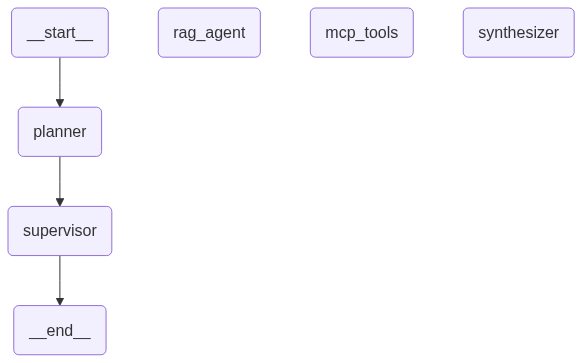

In [6]:
# TODO(1.7): visualize the compiled graph
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



### Test the graph


In [ ]:
# Retrieval-only query
# graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
# Test retrieval-only query
from langchain_core.messages import HumanMessage

query = "What was the net income in 2020?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

print("Plan:", result.get("plan"))
print("\n Step results:")
for i, res in enumerate(result.get("step_results", []), 1):
    print(f"   Step {i}: {res}")

final_answer = result["messages"][-1].content if result.get("messages") else "⚠️ No messages"
print(f"\n✅ Final answer:\n{final_answer}")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
📌 Plan: ['Retrieve: net income in 2020']

 Step results:
   Step 1: Net income in 2020 was ¥455 billion.

✅ Final answer:
The net income in 2020 was ¥455 billion, as found in Step 1.


In [9]:
# Computation-only query
# graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})

from langchain_core.messages import HumanMessage

query = "What is 15% of 2.4 billion?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

print("Plan:", result.get("plan"))
print("\nStep results:")
for i, res in enumerate(result.get("step_results", []), 1):
    print(f"   Step {i}: {res}")

final_answer = result["messages"][-1].content if result.get("messages") else "⚠️ No messages"
print(f"\n✅ Final answer:\n{final_answer}")

Plan: ['Compute: 2.4 billion * 0.15']

Step results:
   Step 1: ([{'type': 'text', 'text': '2.4e9 * 0.15 = 3.6e+08', 'id': 'lc_c3b0d779-6fe7-4a8e-ae10-f419d1b434f9'}], {'structured_content': {'result': '2.4e9 * 0.15 = 3.6e+08'}})

✅ Final answer:
To find 15% of 2.4 billion, we performed a calculation. According to Step 1, 15% of 2.4 billion is equal to 2.4e9 * 0.15, which equals 3.6e+08. This can also be expressed as 360 million. Therefore, 15% of 2.4 billion is 360 million.


In [10]:
# Combined query — show the full step-by-step execution trace
# graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})

from langchain_core.messages import HumanMessage

query = "What was the revenue in 2023, and what would a 10% increase look like?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

print("Plan:")
for i, step in enumerate(result.get("plan", []), 1):
    print(f"   {i}. {step}")

print("\nStep results:")
for i, res in enumerate(result.get("step_results", []), 1):
    print(f"   Step {i}: {res}")

final_answer = result["messages"][-1].content if result.get("messages") else "⚠️ No messages"
print(f"\n✅ Final answer:\n{final_answer}")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Plan:
   1. Retrieve: revenue in 2023
   2. Compute: revenue in 2023 * 1.10

Step results:
   Step 1: ¥16.91 trillion
   Step 2: ([{'type': 'text', 'text': "Error evaluating 'revenue in 2023 * 1.10': Expression contains an unsupported operation", 'id': 'lc_9a8e493c-af73-49bd-91be-7d81819a3692'}], {'structured_content': {'result': "Error evaluating 'revenue in 2023 * 1.10': Expression contains an unsupported operation"}})

✅ Final answer:
The revenue in 2023 was ¥16.91 trillion, as found in Step 1. However, the calculation for a 10% increase could not be determined, as Step 2 resulted in an error message stating "Error evaluating 'revenue in 2023 * 1.10': Expression contains an unsupported operation". Therefore, the exact figure for a 10% increase is unavailable due to this calcul

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [0]:
!python -m pytest tests/test_smoke.py -q


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [0]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"



In [0]:
# TODO(2.2): log + register the model version in Unity Catalog



In [0]:
# TODO(2.3): create/update the serving endpoint; wait for READY; print the URL



### Test the deployed endpoint (Task 2.4)


In [0]:
# curl the endpoint and show the raw response



In [0]:
# Response shape depends on how you logged the model (see README Task 2.4 / GUIDE §7).
#
# Path A — raw LangGraph state (mlflow.langchain.log_model, v1 style):
# import requests
# url = f'{DATABRICKS_HOST}/serving-endpoints/<your-endpoint-name>/invocations'
# r = requests.post(url, headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
#                   json={'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
# print(r.json()[0]['messages'][-1]['content'])
#
# Path B — OpenAI ChatCompletion (mlflow.pyfunc.ChatModel / ChatAgent, v2 style):
# import openai
# client = openai.OpenAI(api_key=DATABRICKS_TOKEN, base_url=f'{DATABRICKS_HOST}/serving-endpoints')
# resp = client.chat.completions.create(model='<your-endpoint-name>',
#     messages=[{'role':'user','content':'What was the net income in 2023?'}])
# print(resp.choices[0].message.content)



## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [0]:
# from client.sdk import DocumentAnalystClient
# c = DocumentAnalystClient(...)
# assert c.health_check() is True
# print(c.ask('What was the net income in 2023?'))



In [0]:
# ask_streaming demo
# for chunk in c.ask_streaming('Summarize FY2023 revenue.'): print(chunk, end='')



In [0]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior

